# Optimizer Comparison: H2

This notebook compares several optimizers for **VQE** on the hydrogen molecule
**H2**.

Goals:

- keep the molecule and ansatz fixed
- run VQE with different optimizers
- compare convergence behaviour and final energies

This isolates the effect of the classical optimization step.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from vqe.core import run_vqe
from common.hamiltonian import get_exact_spectrum

## Setup

We fix:

- molecule: `H2`
- ansatz: `UCCSD`
- step count
- random seed

Only the optimizer changes.

In [2]:
molecule = "H2"
ansatz_name = "UCCSD"
steps = 50
stepsize = 0.2
seed = 0

optimizer_names = [
    "GradientDescent",
    "Adam",
    "RMSProp",
    "Adagrad",
    "NesterovMomentum",
]

## Exact ground-state reference

For a small system like `H2`, we can compare final VQE energies against the
exact ground-state value.

In [3]:
exact_spectrum = np.asarray(get_exact_spectrum(molecule), dtype=float)
exact_spectrum = np.sort(exact_spectrum)
exact_ground_energy = float(exact_spectrum[0])

exact_ground_energy

-1.1372701748841751

## Run VQE for each optimizer

In [4]:
results = {}

for optimizer_name in optimizer_names:
    print(f"Running {optimizer_name} ...")
    res = run_vqe(
        molecule=molecule,
        ansatz_name=ansatz_name,
        optimizer_name=optimizer_name,
        steps=steps,
        stepsize=stepsize,
        seed=seed,
        noisy=False,
        force=True,
        plot=False,
    )
    results[optimizer_name] = res

Running GradientDescent ...
Step 01/50: E = -1.116684 Ha
Step 02/50: E = -1.122738 Ha
Step 03/50: E = -1.127025 Ha
Step 04/50: E = -1.130055 Ha
Step 05/50: E = -1.132192 Ha
Step 06/50: E = -1.133697 Ha
Step 07/50: E = -1.134757 Ha
Step 08/50: E = -1.135503 Ha
Step 09/50: E = -1.136028 Ha
Step 10/50: E = -1.136397 Ha
Step 11/50: E = -1.136657 Ha
Step 12/50: E = -1.136839 Ha
Step 13/50: E = -1.136967 Ha
Step 14/50: E = -1.137057 Ha
Step 15/50: E = -1.137120 Ha
Step 16/50: E = -1.137165 Ha
Step 17/50: E = -1.137196 Ha
Step 18/50: E = -1.137218 Ha
Step 19/50: E = -1.137234 Ha
Step 20/50: E = -1.137245 Ha
Step 21/50: E = -1.137252 Ha
Step 22/50: E = -1.137258 Ha
Step 23/50: E = -1.137261 Ha
Step 24/50: E = -1.137264 Ha
Step 25/50: E = -1.137266 Ha
Step 26/50: E = -1.137267 Ha
Step 27/50: E = -1.137268 Ha
Step 28/50: E = -1.137269 Ha
Step 29/50: E = -1.137269 Ha
Step 30/50: E = -1.137269 Ha
Step 31/50: E = -1.137270 Ha
Step 32/50: E = -1.137270 Ha
Step 33/50: E = -1.137270 Ha
Step 34/50: E =

## Final energies

In [5]:
summary_rows = []

for optimizer_name, res in results.items():
    final_energy = float(res["energy"])
    abs_error = abs(final_energy - exact_ground_energy)
    n_steps = len(res["energies"])

    summary_rows.append((optimizer_name, final_energy, abs_error, n_steps))

summary_rows

[('GradientDescent', -1.13727017423428, 6.498952487277165e-10, 51),
 ('Adam', -1.1371763798704708, 9.379501370432308e-05, 51),
 ('RMSProp', -1.1322372091759902, 0.0050329657081849, 51),
 ('Adagrad', -1.1372701748841751, 0.0, 51),
 ('NesterovMomentum', -1.1372701748794893, 4.685807297732936e-12, 51)]

In [6]:
for optimizer_name, final_energy, abs_error, n_steps in summary_rows:
    print(
        f"{optimizer_name:>20} | "
        f"final = {final_energy:.10f} | "
        f"abs error = {abs_error:.6e} | "
        f"steps = {n_steps}"
    )

     GradientDescent | final = -1.1372701742 | abs error = 6.498952e-10 | steps = 51
                Adam | final = -1.1371763799 | abs error = 9.379501e-05 | steps = 51
             RMSProp | final = -1.1322372092 | abs error = 5.032966e-03 | steps = 51
             Adagrad | final = -1.1372701749 | abs error = 0.000000e+00 | steps = 51
    NesterovMomentum | final = -1.1372701749 | abs error = 4.685807e-12 | steps = 51


## Convergence curves

Plot the energy trajectory for each optimizer on the same axes.

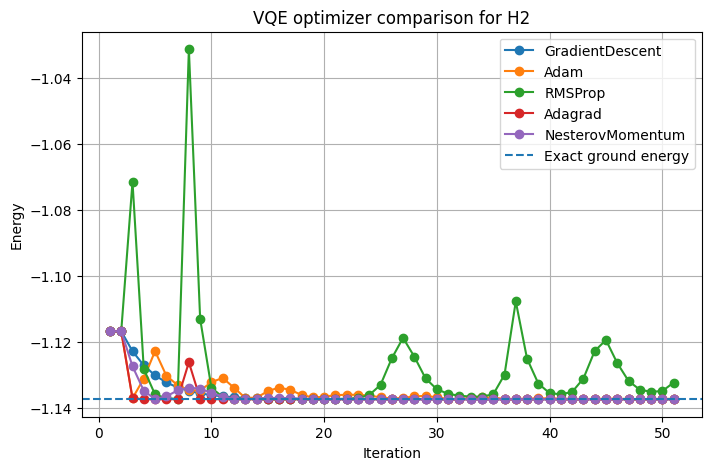

In [7]:
plt.figure(figsize=(8, 5))

for optimizer_name, res in results.items():
    energies = np.asarray(res["energies"], dtype=float)
    plt.plot(
        np.arange(1, len(energies) + 1),
        energies,
        marker="o",
        label=optimizer_name,
    )

plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("VQE optimizer comparison for H2")
plt.grid(True)
plt.legend()
plt.show()

## Final-energy comparison

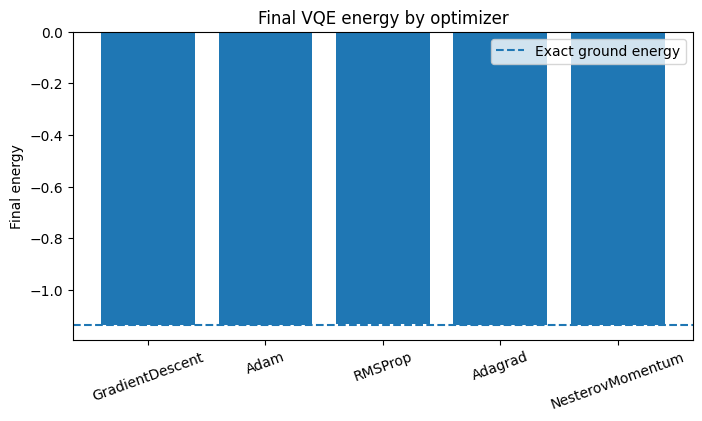

In [8]:
final_energies = [float(results[name]["energy"]) for name in optimizer_names]

plt.figure(figsize=(8, 4))
plt.bar(optimizer_names, final_energies)
plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.ylabel("Final energy")
plt.title("Final VQE energy by optimizer")
plt.xticks(rotation=20)
plt.legend()
plt.show()

## Interpretation

Things to look for:

- which optimizer converges fastest
- which optimizer reaches the lowest final energy
- which optimizer is most stable across iterations

In many small VQE examples, **Adam** is a strong default because it is usually
robust to step-size sensitivity.

Simpler optimizers can still be useful:

- **GradientDescent** as a baseline
- **NesterovMomentum** when the landscape is smooth
- **RMSProp / Adagrad** for adaptive scaling behaviour

## What this notebook showed

We:

- fixed the molecule and ansatz
- compared several classical optimizers
- plotted convergence curves
- compared final energies to the exact ground-state reference

This isolates the classical part of the VQE loop.